<a href="https://colab.research.google.com/github/rifkyh/tugas-1-machine-learning/blob/main/notebook/tugas1_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 1 - Data Preprocessing
| | |
| --- | --- |
| **Mata Kuliah** | : Machine Learning |
|Nama      | : Rifky Hermawan |
|NIM       | : 053102749 |



## Tahap 1 - Load Dataset
Dataset dimuat menggunakan library Pandas. Dataset yang digunakan merupakan file CSV yang berisi informasi mahasiswa dari beberapa program studi.

#### 1. Import Pandas

In [17]:
import pandas as pd

####2. Baca Dataset

In [18]:
df = pd.read_csv("https://raw.githubusercontent.com/rifkyh/tugas-1-machine-learning/refs/heads/main/data/dataset_tugas1_preprocessing.csv")

####3. Cek Data

In [19]:
df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


In [20]:
df.shape

(99, 8)

##Tahap 2 - Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami struktur dan karakteristik dataset sebelum masuk ke tahap preprocessing.

Pada tahap ini dilakukan pemeriksaan:
- Struktur dan tipe data setiap kolom.
- Jumlah missing value pada setiap kolom.
- Statistik deskriptif pada dataset.
- Distribusi data kategorikal untuk memahami karakteristik data.

####2.1 Melihat Beberapa Baris Data

In [21]:
df.head()

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
0,MH001,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,13-04-2020,NaN
1,MH002,Eka,Perempuan,Teknik Komputer,Lulus,E,2020/12/11,28.0
2,MH003,Iwan,Laki-laki,Teknik Komputer,Aktif,NaN,2021/11/21,23.0
3,MH004,Eka,Perempuan,Teknik Komputer,Aktif,D,2021/08/19,18.0
4,MH005,Joko,Perempuan,Data Science,Aktif,C,2020/01/05,26.0


####2.2 Melihat Ukuran **Dataset**

In [22]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 99
Jumlah kolom: 8


####2.3 Cek Struktur dan Tipe Data

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             99 non-null     object 
 1   Nama           99 non-null     object 
 2   Jenis_Kelamin  99 non-null     object 
 3   Prodi          99 non-null     object 
 4   Status         99 non-null     object 
 5   Nilai_Akhir    70 non-null     object 
 6   Tanggal_Ujian  99 non-null     object 
 7   Umur           90 non-null     float64
dtypes: float64(1), object(7)
memory usage: 6.3+ KB


####2.4 Cek Missing Values

In [24]:
df.isnull().sum()

,0
ID,0
Nama,0
Jenis_Kelamin,0
Prodi,0
Status,0
Nilai_Akhir,29
Tanggal_Ujian,0
Umur,9


####2.5 Statistik Deskriptif

In [25]:
df.describe()

,Umur
count,90.000000
mean,23.366667
std,3.763963
min,18.000000
25%,20.000000
50%,23.000000
75%,26.000000
max,30.000000


In [26]:
df.describe(include="all")

,ID,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir,Tanggal_Ujian,Umur
count,99,99,99,99,99,70,99,90.000000
unique,99,10,2,4,4,5,97,NaN
top,MH001,Eka,Laki-laki,Teknik Komputer,Cuti,C,2020/03/31,NaN
freq,1,15,50,28,29,17,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.366667
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.763963
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.000000


In [27]:
df["Nilai_Akhir"].value_counts()

,count
Nilai_Akhir,
C,17
A,16
D,16
B,12
E,9


### Hasil EDA

Dataset terdiri dari 99 baris dan 8 kolom. Terdapat missing value pada kolom `Nilai_Akhir` sebanyak 29 data dan `Umur` sebanyak 9 data.

Kolom `Umur` memiliki tipe data numerik dengan rentang usia 18–30 tahun. Nilai median umur adalah 23 tahun, sedangkan rata-ratanya sekitar 23,37 tahun.

Kolom `Nilai_Akhir` memiliki 5 kategori nilai, yaitu A sampai E. Kategori yang paling sering muncul adalah C.

## Tahap 3 - Menangani Missing Values

Berdasarkan hasil EDA, terdapat missing value pada kolom `Nilai_Akhir` dan `Umur`.

Penanganan missing value dilakukan dengan imputasi menggunakan metode yang sesuai dengan tipe datanya:
- `Umur` menggunakan median karena merupakan data numerik.
- `Nilai_Akhir` menggunakan modus karena merupakan data kategorikal.

In [28]:
median_umur = df["Umur"].median()
modus_nilai = df["Nilai_Akhir"].mode()[0]

print("Median Umur:", median_umur)
print("Modus Nilai Akhir:", modus_nilai)

Median Umur: 23.0
Modus Nilai Akhir: C


####3.1 Imputasi Nilai Hilang

In [29]:
df["Umur"] = df["Umur"].fillna(median_umur)
df["Nilai_Akhir"] = df["Nilai_Akhir"].fillna(modus_nilai)

Memastikan kembali sudah tidak ada Missing Values

In [30]:
df.isnull().sum()

,0
ID,0
Nama,0
Jenis_Kelamin,0
Prodi,0
Status,0
Nilai_Akhir,0
Tanggal_Ujian,0
Umur,0


### Hasil Penanganan Missing Values

Missing value pada kolom `Umur` dan `Nilai_Akhir` telah diisi menggunakan median dan modus. Setelah proses imputasi, seluruh kolom tidak lagi memiliki missing value.

##Tahap 4 - Normalisasi Format Tanggal
Kolom `Tanggal_Ujian` masih memiliki tipe data `object` dan menggunakan beberapa format tanggal yang berbeda. Oleh karena itu, kolom tersebut dikonversi ke tipe data `datetime` agar format tanggal menjadi konsisten dan dapat digunakan dalam proses analisis maupun machine learning.

In [31]:
df["Tanggal_Ujian"] = pd.to_datetime(
    df["Tanggal_Ujian"],
    format="mixed"
)

In [32]:
df["Tanggal_Ujian"].head()

,Tanggal_Ujian
0,2020-04-13
1,2020-12-11
2,2021-11-21
3,2021-08-19
4,2020-01-05


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             99 non-null     object        
 1   Nama           99 non-null     object        
 2   Jenis_Kelamin  99 non-null     object        
 3   Prodi          99 non-null     object        
 4   Status         99 non-null     object        
 5   Nilai_Akhir    99 non-null     object        
 6   Tanggal_Ujian  99 non-null     datetime64[ns]
 7   Umur           99 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 6.3+ KB


### Hasil Normalisasi Tanggal

Kolom `Tanggal_Ujian` berhasil dikonversi dari tipe data `object` menjadi `datetime64[ns]`. Seluruh 99 data pada kolom tersebut berhasil dikonversi tanpa menghasilkan missing value.

##Tahap 5 - Label Encoding

Label Encoding merupakan teknik preprocessing untuk mengubah data kategorikal menjadi representasi numerik agar dapat diproses oleh algoritma machine learning.

Pada tahap ini, Label Encoding diterapkan pada kolom `Nama`, `Jenis_Kelamin`, `Prodi`, `Status`, dan `Nilai_Akhir` sesuai dengan instruksi tugas.

#### 5.1 Pemeriksaan Data Kategorikal

Sebelum melakukan Label Encoding, dilakukan pemeriksaan terhadap nilai unik pada setiap kolom kategorikal untuk mengetahui kategori yang terdapat dalam dataset.

In [36]:
kategori_kolom = [
    "Nama",
    "Jenis_Kelamin",
    "Prodi",
    "Status",
    "Nilai_Akhir"
]

for column in kategori_kolom:
  print(f"{column}:")
  print(df[column].unique())
  print()

Nama:
['Iwan' 'Eka' 'Joko' 'Gita' 'Adi' 'Hana' 'Dina' 'Budi' 'Citra' 'Farhan']

Jenis_Kelamin:
['Laki-laki' 'Perempuan']

Prodi:
['Teknik Komputer' 'Data Science' 'Informatika' 'Sistem Informasi']

Status:
['Aktif' 'Lulus' 'DO' 'Cuti']

Nilai_Akhir:
['C' 'E' 'D' 'B' 'A']



####5.2 Verifikasi missing value

In [39]:
df["Nilai_Akhir"].isnull().sum()

np.int64(0)

### 5.3 Proses Label Encoding

Setiap kategori pada kolom yang dipilih akan dikonversi menjadi nilai numerik menggunakan `LabelEncoder` dari Scikit-learn. Proses ini dilakukan pada setiap kolom secara terpisah agar setiap kategori memiliki representasi angka sesuai dengan kolomnya.

In [41]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in kategori_kolom:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le

### 5.4 Hasil Label Encoding

Setelah proses Label Encoding, data kategorikal telah dikonversi menjadi representasi numerik. Pemeriksaan dilakukan untuk memastikan setiap kolom sudah memiliki nilai numerik dan tidak terdapat missing value.

In [42]:
df[kategori_kolom].head(10)

,Nama,Jenis_Kelamin,Prodi,Status,Nilai_Akhir
0,8,0,3,0,2
1,4,1,3,3,4
2,8,0,3,0,2
3,4,1,3,0,3
4,9,1,0,0,2
5,6,1,3,0,2
6,0,0,0,2,2
7,9,1,0,1,2
8,8,0,1,0,1
9,7,0,1,0,3


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   ID             99 non-null     object        
 1   Nama           99 non-null     int64         
 2   Jenis_Kelamin  99 non-null     int64         
 3   Prodi          99 non-null     int64         
 4   Status         99 non-null     int64         
 5   Nilai_Akhir    99 non-null     int64         
 6   Tanggal_Ujian  99 non-null     datetime64[ns]
 7   Umur           99 non-null     float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(1)
memory usage: 6.3+ KB


### 5.5 Pemetaan Label Encoding

Pemetaan dilakukan untuk mengetahui representasi numerik dari setiap kategori pada kolom yang telah di-encode. Nilai numerik yang dihasilkan merupakan label kategori dan tidak selalu menunjukkan tingkatan atau besaran tertentu.

In [46]:
df_original = pd.read_csv("https://raw.githubusercontent.com/rifkyh/tugas-1-machine-learning/refs/heads/main/data/dataset_tugas1_preprocessing.csv")

In [47]:
df_original["Prodi"] = (
    df_original["Prodi"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_original["Nilai_Akhir"] = df_original["Nilai_Akhir"].fillna(
    df_original["Nilai_Akhir"].mode()[0]
)

In [48]:
for column in kategori_kolom:
    le = LabelEncoder()
    le.fit(df_original[column].dropna())

    print(f"{column}:")
    for category, encoded_value in zip(le.classes_, le.transform(le.classes_)):
        print(f"  {category} = {encoded_value}")
    print()

Nama:
  Adi = 0
  Budi = 1
  Citra = 2
  Dina = 3
  Eka = 4
  Farhan = 5
  Gita = 6
  Hana = 7
  Iwan = 8
  Joko = 9

Jenis_Kelamin:
  Laki-laki = 0
  Perempuan = 1

Prodi:
  Data Science = 0
  Informatika = 1
  Sistem Informasi = 2
  Teknik Komputer = 3

Status:
  Aktif = 0
  Cuti = 1
  DO = 2
  Lulus = 3

Nilai_Akhir:
  A = 0
  B = 1
  C = 2
  D = 3
  E = 4



### Hasil Label Encoding

Label Encoding berhasil diterapkan pada kolom `Nama`, `Jenis_Kelamin`, `Prodi`, `Status`, dan `Nilai_Akhir`. Setiap kategori telah dikonversi menjadi nilai numerik.

Nilai numerik yang dihasilkan berfungsi sebagai representasi kategori dan tidak selalu menunjukkan tingkatan atau besaran. Pada `Nilai_Akhir`, hasil encoding A sampai E secara kebetulan mengikuti urutan nilai kategorinya.

##Tahap 6 - Train-Test Split

Dataset dibagi menjadi data training dan data testing dengan perbandingan 80:20 sesuai dengan instruksi tugas.

Data training digunakan sebagai data latih, sedangkan data testing digunakan sebagai data uji.

####6.1 Melakukan Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    df,
    test_size=0.2, #20% data masuk testing dan sisanya 80% training
    random_state=42 #agar pembagian datanya konsisten jika notebook dijalankan ulang
)

In [50]:
print("Jumlah data training:", len(train_data))
print("Jumlah data testing:", len(test_data))

Jumlah data training: 79
Jumlah data testing: 20


### Hasil Train-Test Split

Dataset berhasil dibagi menjadi data training dan data testing dengan rasio 80:20. Dari total 99 data, sebanyak 79 data digunakan sebagai data training dan 20 data digunakan sebagai data testing.

##Tahap 7 - Visualisasi Data

Visualisasi digunakan untuk membantu memahami distribusi dan karakteristik data secara lebih mudah. Pada tahap ini dibuat histogram untuk melihat distribusi `Umur` dan bar chart untuk melihat jumlah mahasiswa pada setiap `Prodi`.

In [51]:
import matplotlib.pyplot as plt

### 7.1 Distribusi Umur

Histogram digunakan untuk melihat distribusi umur mahasiswa berdasarkan data yang telah melalui proses preprocessing.

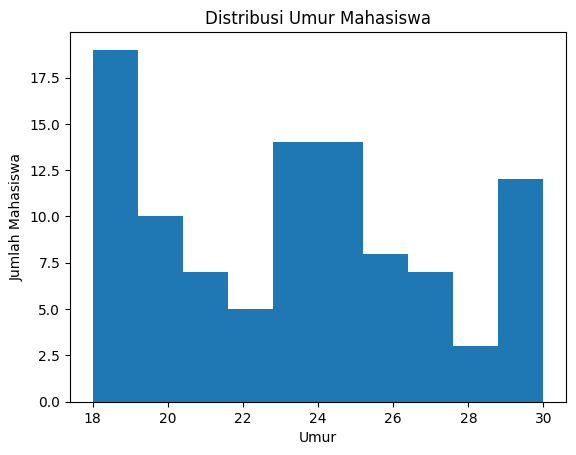

In [52]:
plt.hist(df["Umur"], bins=10)
plt.xlabel("Umur")
plt.ylabel("Jumlah Mahasiswa")
plt.title("Distribusi Umur Mahasiswa")
plt.show()

### 7.2 Jumlah Mahasiswa per Program Studi

Bar chart digunakan untuk melihat jumlah mahasiswa pada setiap program studi. Visualisasi menggunakan nama program studi agar distribusi antar program studi dapat lebih mudah dibandingkan.

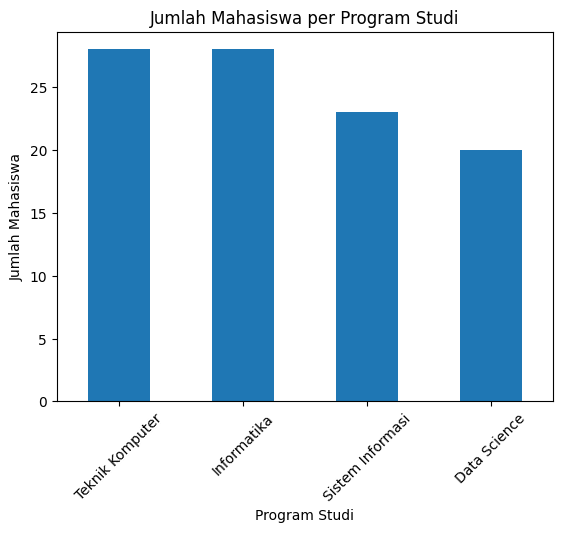

In [53]:
df_original["Prodi"].value_counts().plot(kind="bar")

plt.xlabel("Program Studi")
plt.ylabel("Jumlah Mahasiswa")
plt.title("Jumlah Mahasiswa per Program Studi")
plt.xticks(rotation=45)
plt.show()

### Hasil Visualisasi

Berdasarkan histogram distribusi umur, jumlah mahasiswa paling banyak berada pada rentang umur 18–19 tahun.

Kemudian, berdasarkan bar chart jumlah mahasiswa per program studi, Teknik Komputer dan Informatika memiliki jumlah mahasiswa yang sama dalam dataset. Hal ini menunjukkan bahwa kedua program studi tersebut memiliki jumlah observasi yang seimbang pada dataset.

##Kesimpulan

Berdasarkan proses preprocessing yang telah dilakukan, dataset berhasil diperiksa dan dipersiapkan untuk tahap pengolahan data selanjutnya.

Tahapan yang dilakukan meliputi pemeriksaan struktur dan karakteristik data melalui EDA, penanganan missing value pada kolom `Umur` dan `Nilai_Akhir`, normalisasi format tanggal pada `Tanggal_Ujian`, serta konversi data kategorikal menggunakan Label Encoding.

Dataset kemudian dibagi menjadi data training dan testing dengan rasio 80:20. Visualisasi juga dilakukan untuk melihat distribusi umur mahasiswa dan jumlah mahasiswa berdasarkan program studi.

Hasil preprocessing menunjukkan bahwa dataset telah memiliki format data yang lebih konsisten dan tidak memiliki missing value sehingga dapat digunakan untuk tahap analisis atau pemodelan machine learning selanjutnya.